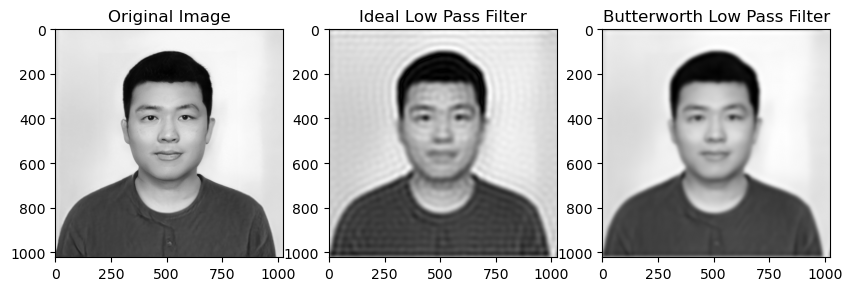

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ideal_low_pass_filter(image, radius):
    dft = np.fft.fft2(image)
    dft_shift = np.fft.fftshift(dft)
    rows, cols = image.shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    
    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i - crow) ** 2 + (j - ccol) ** 2) <= radius:
                mask[i, j] = 1
    
    filtered_dft = dft_shift * mask
    idft_shift = np.fft.ifftshift(filtered_dft)
    filtered_image = np.fft.ifft2(idft_shift)
    return np.abs(filtered_image)

def butterworth_low_pass_filter(image, radius, order=2):
    dft = np.fft.fft2(image)
    dft_shift = np.fft.fftshift(dft)
    rows, cols = image.shape
    crow, ccol = rows // 2 , cols // 2
    
    mask = np.zeros((rows, cols), np.float32)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - crow) ** 2 + (j - ccol) ** 2)
            mask[i, j] = 1 / (1 + (distance / radius) ** (2 * order))
    
    filtered_dft = dft_shift * mask
    idft_shift = np.fft.ifftshift(filtered_dft)
    filtered_image = np.fft.ifft2(idft_shift)
    return np.abs(filtered_image)

# Load image
image = cv2.imread(r"D:\AP22110010458\digital-image-preprocessing\assets\photo.jpg", cv2.IMREAD_GRAYSCALE)

# Apply low-pass filters
radius = 30
ideal_filtered = ideal_low_pass_filter(image, radius)
butterworth_filtered = butterworth_low_pass_filter(image, radius)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 3, 2)
plt.imshow(ideal_filtered, cmap='gray')
plt.title('Ideal Low Pass Filter')
plt.subplot(1, 3, 3)
plt.imshow(butterworth_filtered, cmap='gray')
plt.title('Butterworth Low Pass Filter')
plt.show()
